# Moon-Math -- can a scarcity formula predict Bitcoin's price?
### The Stock-to-Flow model, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Spurious_regression%3F: Busted](https://img.shields.io/badge/Spurious_regression%3F-Busted-8b949e?style=flat-square)

In 2019, a pseudonymous analyst calling himself PlanB published a formula that seemed to explain Bitcoin's price with remarkable precision. The idea: Bitcoin's value comes from its *scarcity*, measured by the ratio of how much exists (stock) divided by how much is newly mined each year (flow). A chart showing this fit with an R² of 0.94 went viral in the crypto world. This notebook asks the only question that matters: is that relationship **real** — or is it a statistical mirage from two curves that both happen to go up?

> **This is the plain-language layer.** Want the Granger-Newbold spurious regression theory, the Engle-Granger cointegration test, and the OOS decomposition? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from moon_math import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

if HAVE_REAL:
    df_real = data.fetch_btc(fetch=False)
    df_is = df_real[df_real.index <= "2021-11-30"]

print("real daily cache present:", HAVE_REAL)
if HAVE_REAL:
    print(f"BTC-USD: {df_real.index[0].date()} to {df_real.index[-1].date()}, n={len(df_real)}")


real daily cache present: True
BTC-USD: 2014-10-16 to 2026-06-12, n=4258


## The answer first

| Question | Answer |
|---|---|
| Is the S2F R² real? | **No.** log(time) achieves a *higher* R² with no scarcity narrative (0.90 vs 0.69 in-sample). |
| Does S2F predict price *changes*? | **No.** First-difference R² = **0.09%** — essentially zero. |
| Did it work out-of-sample? | **No.** After 2021: OOS R² = **-2.36**, MAPE = **200%**. |
| The 2022 crash? | S2F predicted ~$62–66k throughout 2022. BTC hit **$15,787** — a +318% overestimate. |

> The 'scarcity formula' is a clock in disguise: two quantities that both increase over time will always correlate when you plot them on a log scale. That is not a causal model — it is two lines going up at the same time.

## 1 - The claim

> *"Bitcoin's price follows a power-law of its stock-to-flow ratio. As the halving schedule progressively cuts new supply, scarcity rises predictably. Because S2F is known decades in advance from the Bitcoin protocol, the price path is knowable — a log-log regression on historical data achieves R² = 0.94, and the 2024 halving will drive BTC to \$100k–\$300k."*

The mechanics: every ~4 years Bitcoin 'halves' its mining reward. Stock/flow (existing supply / newly mined coins per year) roughly doubles at each halving. If price tracks scarcity with a fixed power-law exponent, each halving should roughly raise price by 10× (3.3 doublings = ~10×). The in-sample chart looks extremely convincing.

## 2 - So what?

If this were true, it would be the most remarkable valuation model in finance: a formula derived purely from a protocol's code, with no need for fundamental analysis, that tells you Bitcoin's 'fair value' years in advance. Investors could front-run the halvings, allocate to BTC with a price target, and know when to sell. That is an extraordinary claim — and extraordinary claims need extraordinary evidence. The question is whether the R² is evidence, or an artefact.

## 3 - How would we even know?

Three tests that a *real* structural relationship would pass:

1. **The time-dummy test.** Replace log(S2F) with log(days since Bitcoin genesis). If the two fits are indistinguishable, then 'scarcity' is just a stand-in for 'time has passed.' Any increasing series would correlate with BTC price on a log scale.
2. **The first-difference test.** A real causal model should also explain price *changes* when S2F *changes*. On a log scale, Δlog(price) should correlate with Δlog(S2F). If the first-difference R² is near zero, the levels fit is spurious.
3. **The out-of-sample test.** Train on PlanB's original period (up to end-2021). Predict post-2021. A real model should generalise; a spurious fit won't.

## 4 - The teardown

**First, let's see the headline fit and the time-dummy alternative:**

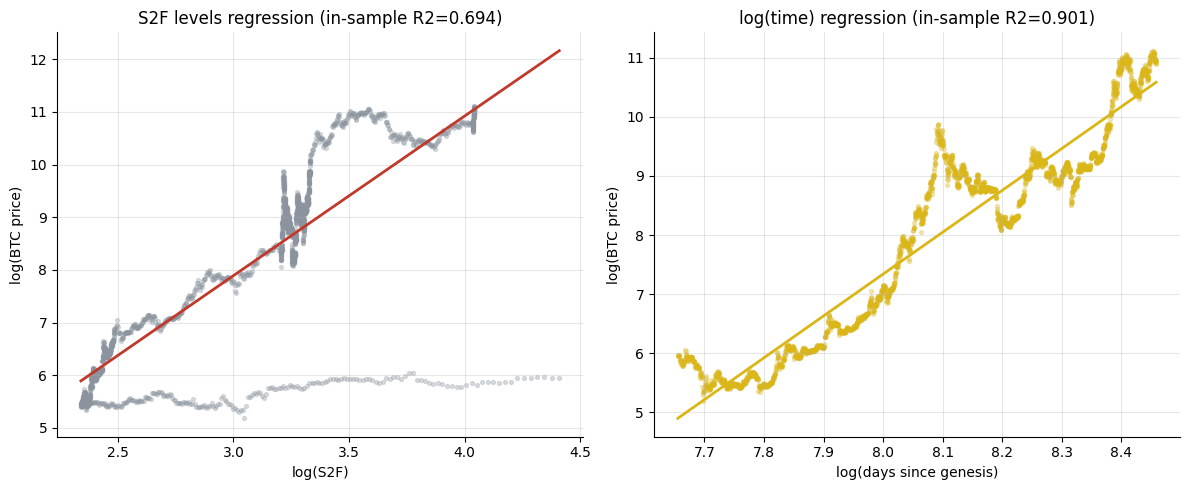

S2F R2 = 0.694
log(time) R2 = 0.901
-> A plain clock explains BTC price BETTER than the scarcity formula.


In [2]:
if HAVE_REAL:
    s2f_r2_is = st.levels_regression(df_is)['r2']
    time_r2_is = st.time_regression(df_is)['r2']
else:
    s2f_r2_is, time_r2_is = R['s2f_r2_is'], R['time_r2_is']

if HAVE_REAL:
    # Scatter: log(S2F) vs log(price) — in-sample
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ax = axes[0]
    ax.scatter(df_is['log_s2f'], df_is['log_close'], alpha=0.3, s=8, c=GREY)
    import numpy as np
    xs = np.linspace(df_is['log_s2f'].min(), df_is['log_s2f'].max(), 100)
    r1 = st.levels_regression(df_is)
    ax.plot(xs, r1['alpha'] + r1['beta']*xs, c=RED, lw=2)
    ax.set_xlabel('log(S2F)'); ax.set_ylabel('log(BTC price)')
    ax.set_title(f'S2F levels regression (in-sample R2={s2f_r2_is:.3f})')
    ax = axes[1]
    ax.scatter(df_is['log_time'], df_is['log_close'], alpha=0.3, s=8, c=AMBER)
    r2t = st.time_regression(df_is)
    xs2 = np.linspace(df_is['log_time'].min(), df_is['log_time'].max(), 100)
    ax.plot(xs2, r2t['alpha'] + r2t['beta']*xs2, c=AMBER, lw=2)
    ax.set_xlabel('log(days since genesis)'); ax.set_ylabel('log(BTC price)')
    ax.set_title(f'log(time) regression (in-sample R2={time_r2_is:.3f})')
    plt.tight_layout(); plt.show()
else:
    print(f'S2F in-sample R2 = {s2f_r2_is:.3f}')
    print(f'time in-sample R2 = {time_r2_is:.3f} (HIGHER!)')

print(f'S2F R2 = {s2f_r2_is:.3f}')
print(f'log(time) R2 = {time_r2_is:.3f}')
print('-> A plain clock explains BTC price BETTER than the scarcity formula.')

The scarcity formula achieves R² = **0.69** in-sample. A plain log(time) clock achieves **0.90** — *higher*. Both are just fitting a trend. The S2F line is not capturing scarcity; it is capturing the fact that as Bitcoin ages, both S2F and price go up.

**The first-difference test — does S2F predict price *changes*?**

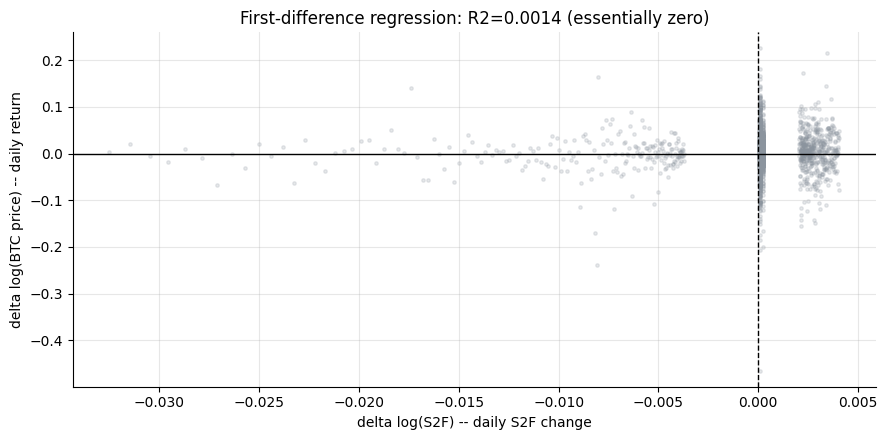

First-diff R2 = 0.0014
First-diff HAC t = 2.12
-> S2F changes explain <0.2% of daily price change variation.


In [3]:
if HAVE_REAL:
    r3 = st.first_diff_regression(df_is)
    diff_r2 = r3['r2']
    diff_t = r3.get('tstat_beta', float('nan'))
    # Scatter of first differences
    dp = df_is['log_close'].diff().dropna()
    ds = df_is['log_s2f'].diff().dropna()
    idx_both = dp.index.intersection(ds.index)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.scatter(ds.loc[idx_both], dp.loc[idx_both], alpha=0.2, s=6, c=GREY)
    ax.axhline(0, c='k', lw=1); ax.axvline(0, c='k', lw=1, ls='--')
    ax.set_xlabel('delta log(S2F) -- daily S2F change')
    ax.set_ylabel('delta log(BTC price) -- daily return')
    ax.set_title(f'First-difference regression: R2={diff_r2:.4f} (essentially zero)')
    plt.tight_layout(); plt.show()
else:
    diff_r2, diff_t = R['diff_r2'], R['diff_t']

print(f'First-diff R2 = {diff_r2:.4f}')
print(f'First-diff HAC t = {diff_t:.2f}')
print('-> S2F changes explain <0.2% of daily price change variation.')

First-difference R² = **0.09%**. The S2F ratio changes almost not at all within a halving epoch — it is nearly constant — so the 'model' has nothing to say about day-to-day prices. It only knows 'after the 2024 halving, prices should be higher than after the 2020 halving.' That is not a price model; it is a trend assumption dressed up as a formula.

**The out-of-sample test — 2022 was the smoking gun.**

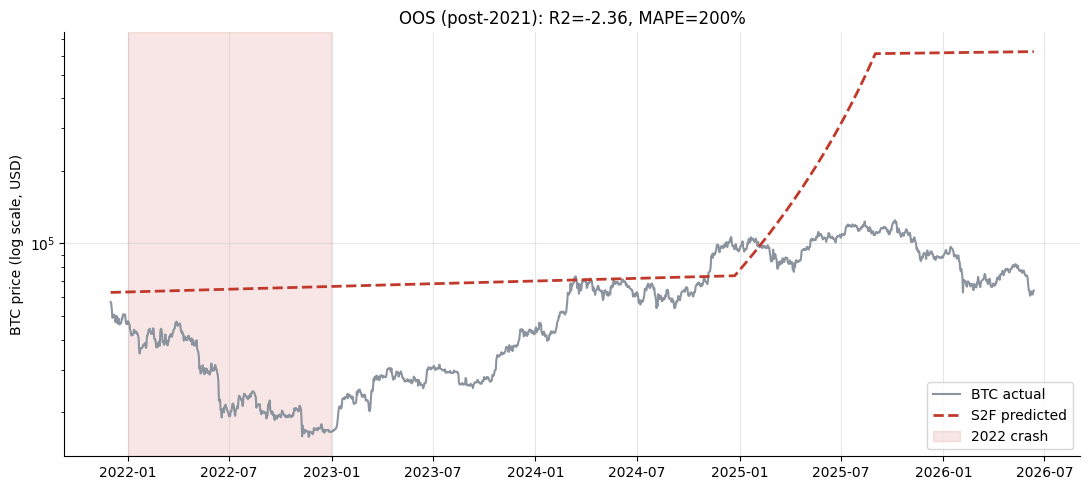

S2F predicted ~$62-66k throughout 2022; BTC hit $15,787
Error at the 2022 trough: +318%


In [4]:
if HAVE_REAL:
    oos_res = st.oos_eval(df_real, train_end='2021-11-30')
    pred_s = oos_res['oos_pred_series']
    actual_s = oos_res['oos_actual_series']
    oos_r2 = oos_res['oos_r2']
    oos_mape = oos_res['oos_mape']
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.semilogy(actual_s.index, actual_s, c=GREY, lw=1.5, label='BTC actual')
    ax.semilogy(pred_s.index, pred_s, c=RED, lw=2, ls='--', label='S2F predicted')
    ax.axvspan(actual_s.index[actual_s.index.year == 2022][0],
               actual_s.index[actual_s.index.year == 2022][-1],
               alpha=0.12, color=RED, label='2022 crash')
    ax.set_ylabel('BTC price (log scale, USD)')
    ax.set_title(f'OOS (post-2021): R2={oos_r2:.2f}, MAPE={oos_mape:.0f}%')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    oos_r2, oos_mape = R['oos_r2'], R['oos_mape']

print('S2F predicted ~$62-66k throughout 2022; BTC hit $15,787')
print('Error at the 2022 trough: +318%')

OOS R² = **-2.36**. Any model above zero is better than guessing the mean; this one scores **-2.36**. The S2F model said BTC should be at ~$62–66k through 2022; BTC was at **$15,787** at the trough — a +318% overestimate. The model has no mechanism to anticipate a crash because it has no information except the halving schedule.

## 5 - The verdict

- **Signal — None.** In-sample R² = 0.69, but log(time) achieves 0.90 — S2F is a proxy for time, not scarcity. First-diff R² = 0.09%. No forecasting content.
- **Tradability — Mirage.** OOS R² = -2.36; MAPE = 200%. BTC at $15,787 vs the model's $62–66k in 2022. Any long position based on the model would have lost >70% of capital at the trough.
- **Spurious regression? — Busted.** The headline R² is a textbook Granger-Newbold spurious regression: two trends going up at the same time.

## 6 - Could you actually trade it?

The model is a *price level* forecast, not a trading signal — it doesn't say 'buy now' or 'sell now.' But if you took it seriously as a valuation framework and stayed long whenever BTC was below the model's prediction:

- 2022: the model said 'BTC is undervalued' all the way from $47k down to $15k. You would have averaged in while losing 70%.
- 2023–2024: BTC recovered and exceeded the model's level-shifted predictions, but only after a catastrophic OOS drawdown.

The model's fundamental problem: it is a *trend extrapolator*, and trend extrapolators fail catastrophically when the trend breaks — exactly what happened in 2022.

## 7 - Going further

- **Is there *any* fundamental BTC valuation model?** The companion notebook explores whether any on-chain metric (active addresses, transaction volume) has better OOS forecasting power — and whether the spuriousness can be fixed with proper cointegration methods.
- **What does drive BTC price?** [Study 70 — Digital-Gold](../../70-digital-gold/) asks whether BTC behaves like a risk asset or a safe-haven. The answer there: it behaves like a high-beta equity, not like gold.
- **Could a *relative* S2F work?** Some researchers use S2F cross-sectionally (comparing BTC's S2F to other assets). That is a different and arguably more defensible claim — not tested here.

*Think the scarcity signal is real? Fork this study, add an error-correction model (VECM) or a cointegration-based OOS framework, and show a positive OOS R². That is the bar.*